# TCRB Finetuning Entrypoint Notebook

This notebook is a practical entrypoint for the finetuning workflow in this repository.

You can run it locally or on Colab/Kaggle GPU. It does three core things:
1. Builds finetuning datasets from benchmark traces (`tcrb finetune-data`)
2. Summarizes dataset quality so you can judge whether training data is usable
3. Computes base-vs-finetuned delta metrics (`tcrb eval-delta`) and explains what they mean

In [1]:
!nvidia-smi

Thu Apr  2 08:11:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from collections import Counter
from pathlib import Path


REPO_NAME = 'tool-calling-reliability-benchmark'
REPO_URL = 'https://github.com/aaliyan1230/tool-calling-reliability-benchmark.git'


def find_repo_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
            return candidate
    return None


repo_root = find_repo_root(Path.cwd())
if repo_root is None:
    kaggle_repo = Path('/kaggle/working') / REPO_NAME
    if not kaggle_repo.exists():
        print(f'[setup] Cloning repo to {kaggle_repo} ...')
        subprocess.run(['git', 'clone', REPO_URL, str(kaggle_repo)], check=True)
    repo_root = kaggle_repo

REPO_ROOT = repo_root.resolve()
os.chdir(REPO_ROOT)

if shutil.which('uv') is None:
    print('[setup] uv not found; installing uv...')
    subprocess.run(['python', '-m', 'pip', 'install', '-q', 'uv'], check=True)

print('Repo root:', REPO_ROOT)
print('Kernel cwd:', Path.cwd())

[setup] Cloning repo to /kaggle/working/tool-calling-reliability-benchmark ...


Cloning into '/kaggle/working/tool-calling-reliability-benchmark'...


Repo root: /kaggle/working/tool-calling-reliability-benchmark
Kernel cwd: /kaggle/working/tool-calling-reliability-benchmark


## 1) Pick Source Runs and Build Finetune Data

The command below converts benchmark attempt traces into training/eval JSONL.

By default, this notebook can merge multiple `runs/*/result.json` files to increase data coverage before splitting.

In [12]:
import random

VALIDATION_SPLIT = 0.25
MIN_EVAL_PER_POLICY = 1
USE_MULTI_SOURCE_DATA = True
MAX_SOURCE_RESULTS = 8
ALLOW_FINETUNED_SOURCES = False
ALLOW_OPEN_WORKLOAD_SOURCES = False

OUTPUT_DIR = REPO_ROOT / 'finetuned-models' / 'training-notebook'
WORKLOAD_PATH = REPO_ROOT / 'workloads' / 'sample_tasks.json'

preferred_sources = [
    REPO_ROOT / 'runs' / 'smoke-baseline' / 'result.json',
    REPO_ROOT / 'runs' / 'run-policy-native-sanity' / 'result.json',
]

all_result_files = list((REPO_ROOT / 'runs').glob('*/result.json'))

def source_allowed(path: Path) -> bool:
    name = path.parent.name.lower()
    if not ALLOW_FINETUNED_SOURCES and ('finetuned' in name or '-ft-' in name or name.startswith('ft-')):
        return False
    if not ALLOW_OPEN_WORKLOAD_SOURCES and ('-open-' in name or name.startswith('open-')):
        return False
    return True

def source_priority(path: Path) -> tuple[int, float]:
    # Higher rank first. Prefer baseline/native/smoke traces and de-prioritize notebook-generated base runs.
    name = path.parent.name.lower()
    rank = 0
    if 'smoke-baseline' in name:
        rank += 100
    if 'native' in name:
        rank += 60
    if 'baseline' in name:
        rank += 50
    if 'smoke' in name:
        rank += 25
    if 'sanity' in name:
        rank += 15

    if 'kaggle-notebook-base' in name:
        rank -= 35
    if 'kaggle-notebook' in name:
        rank -= 10

    mtime = path.stat().st_mtime if path.exists() else 0.0
    return (rank, mtime)

filtered_result_files = [p for p in all_result_files if source_allowed(p)]
filtered_result_files = sorted(filtered_result_files, key=source_priority, reverse=True)

# Prioritize preferred files, then fill from ranked artifacts.
ordered_sources = []
seen = set()
for p in [*preferred_sources, *filtered_result_files]:
    if p.exists() and p not in seen:
        ordered_sources.append(p)
        seen.add(p)

selected_sources = ordered_sources[:MAX_SOURCE_RESULTS] if USE_MULTI_SOURCE_DATA else ordered_sources[:1]

if not selected_sources:
    print('[data] No existing result.json found, running a baseline benchmark first...')
    gen_label = 'kaggle-notebook-baseline'
    gen_cmd = [
        'uv', 'run', 'tcrb', 'run',
        '--config', str(REPO_ROOT / 'configs' / 'baseline.json'),
        '--workload', str(WORKLOAD_PATH),
        '--label', gen_label,
    ]
    print('Running:', ' '.join(gen_cmd))
    gen_completed = subprocess.run(gen_cmd, text=True, capture_output=True, check=False)
    print(gen_completed.stdout)
    if gen_completed.returncode != 0:
        print(gen_completed.stderr)
        raise RuntimeError(f'baseline generation failed with code {gen_completed.returncode}')
    selected_sources = [REPO_ROOT / 'runs' / gen_label / 'result.json']

print('[data] Selected source artifacts:')
for p in selected_sources:
    print(' -', p)

def merge_result_payloads(result_paths: list[Path], out_path: Path) -> Path:
    merged_task_results = []
    source_rows = []
    for p in result_paths:
        payload = json.loads(p.read_text(encoding='utf-8'))
        rows = payload.get('task_results', [])
        merged_task_results.extend(rows)
        source_rows.append({'path': str(p), 'task_results': len(rows)})

    merged = {
        'generated_by': 'finetuning_entrypoint_notebook',
        'source_result_files': source_rows,
        'task_results': merged_task_results,
    }
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(json.dumps(merged, indent=2), encoding='utf-8')
    return out_path

if len(selected_sources) > 1:
    INPUT_RESULT_JSON = merge_result_payloads(
        selected_sources,
        OUTPUT_DIR / 'merged_input_result.json',
    )
    print('[data] Merged input JSON:', INPUT_RESULT_JSON)
else:
    INPUT_RESULT_JSON = selected_sources[0]

cmd = [
    'uv', 'run', 'tcrb', 'finetune-data',
    '--input-json', str(INPUT_RESULT_JSON),
    '--output-dir', str(OUTPUT_DIR),
    '--validation-split', str(VALIDATION_SPLIT),
    '--seed', '42',
    '--workload', str(WORKLOAD_PATH),
]

print('Running:', ' '.join(cmd))
completed = subprocess.run(cmd, text=True, capture_output=True, check=False)
if completed.returncode == 0:
    print(completed.stdout)
else:
    print('[data] CLI finetune-data unavailable, using notebook fallback builder...')
    payload = json.loads(INPUT_RESULT_JSON.read_text(encoding='utf-8'))

    with WORKLOAD_PATH.open('r', encoding='utf-8') as f:
        workload_payload = json.load(f)

    task_lookup = {
        t['task_id']: {
            'primary_tool': t['primary_tool'],
            'fallback_tools': list(t.get('fallback_tools', [])),
            'required_schema': list(t.get('required_schema', [])),
        }
        for t in workload_payload.get('tasks', [])
    }

    examples = []
    for row in payload.get('task_results', []):
        task_id = str(row.get('task_id', ''))
        policy = str(row.get('policy', ''))
        planner_id = str(row.get('planner_id', ''))
        attempted_before = []
        last_status = None
        for attempt in row.get('attempts', []):
            status = str(attempt.get('status', ''))
            tool_name = str(attempt.get('tool_name', '')).strip()
            invalid_tool_call = bool(attempt.get('invalid_tool_call', False))
            if status != 'success' or invalid_tool_call or not tool_name:
                attempted_before.append(tool_name)
                last_status = status
                continue

            prompt = {
                'task_id': task_id,
                'policy': policy,
                'planner_id': planner_id,
                'attempt_number': int(attempt.get('attempt_number', 0)),
                'attempted_tools': [x for x in attempted_before if x],
                'last_status': last_status,
            }
            prompt.update(task_lookup.get(task_id, {}))
            examples.append({'prompt': prompt, 'completion': {'tool_name': tool_name}})
            attempted_before.append(tool_name)
            last_status = status

    # Deduplicate
    seen = set()
    deduped = []
    for ex in examples:
        fp = json.dumps(ex, sort_keys=True)
        if fp in seen:
            continue
        seen.add(fp)
        deduped.append(ex)

    # Stratified split to keep policy coverage in eval on small datasets.
    by_policy = {}
    for ex in deduped:
        policy = str(ex.get('prompt', {}).get('policy', 'unknown'))
        by_policy.setdefault(policy, []).append(ex)

    rng = random.Random(42)
    train_rows = []
    eval_rows = []

    for policy, rows in by_policy.items():
        rows_copy = list(rows)
        rng.shuffle(rows_copy)
        desired_eval = int(round(len(rows_copy) * float(VALIDATION_SPLIT)))
        eval_count = max(MIN_EVAL_PER_POLICY, desired_eval) if len(rows_copy) > 1 else 0
        eval_count = min(eval_count, max(0, len(rows_copy) - 1))
        eval_rows.extend(rows_copy[:eval_count])
        train_rows.extend(rows_copy[eval_count:])

    rng.shuffle(train_rows)
    rng.shuffle(eval_rows)

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    TRAIN_JSONL = OUTPUT_DIR / 'train_dataset.jsonl'
    EVAL_JSONL = OUTPUT_DIR / 'eval_dataset.jsonl'
    with TRAIN_JSONL.open('w', encoding='utf-8') as f:
        for row in train_rows:
            f.write(json.dumps(row, sort_keys=True) + '\n')
    with EVAL_JSONL.open('w', encoding='utf-8') as f:
        for row in eval_rows:
            f.write(json.dumps(row, sort_keys=True) + '\n')

    print(f'[data] Fallback build complete: total={len(deduped)} train={len(train_rows)} eval={len(eval_rows)} split={VALIDATION_SPLIT:.2f}')
    print('[data] Policy eval coverage:', sorted({str(r.get('prompt', {}).get('policy', 'unknown')) for r in eval_rows}))

TRAIN_JSONL = OUTPUT_DIR / 'train_dataset.jsonl'
EVAL_JSONL = OUTPUT_DIR / 'eval_dataset.jsonl'
print('Source result JSON:', INPUT_RESULT_JSON)
print('Train JSONL:', TRAIN_JSONL)
print('Eval JSONL:', EVAL_JSONL)

[data] Selected source artifacts:
 - /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-baseline/result.json
 - /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7/result.json
[data] Merged input JSON: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/merged_input_result.json
Running: uv run tcrb finetune-data --input-json /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/merged_input_result.json --output-dir /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook --validation-split 0.25 --seed 42 --workload /kaggle/working/tool-calling-reliability-benchmark/workloads/sample_tasks.json
Examples total: 29
Train examples: 22
Eval examples: 7
Wrote train dataset: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/train_dataset.jsonl
Wrote eval dataset: /kaggle/working/tool-calling-reliability-benc

## 2) Inspect Dataset Quality

These numbers tell you if training data is healthy:
- More examples is generally better
- Tool label distribution should not be extremely collapsed
- Attempt-number and policy spread should look plausible

In [13]:
def load_jsonl(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

train_rows = load_jsonl(TRAIN_JSONL)
eval_rows = load_jsonl(EVAL_JSONL)
all_rows = train_rows + eval_rows

tool_counts = Counter(row['completion']['tool_name'] for row in all_rows)
policy_counts = Counter(row['prompt'].get('policy', 'unknown') for row in all_rows)
attempt_counts = Counter(row['prompt'].get('attempt_number', 0) for row in all_rows)

print('Total examples:', len(all_rows))
print('Train examples:', len(train_rows))
print('Eval examples:', len(eval_rows))
print('Unique tools:', len(tool_counts))
print('Tool distribution:', dict(tool_counts))
print('Policy distribution:', dict(policy_counts))
print('Attempt-number distribution:', dict(attempt_counts))

Total examples: 29
Train examples: 22
Eval examples: 7
Unique tools: 5
Tool distribution: {'search_docs_v1': 14, 'voice_lookup_stream': 8, 'voice_lookup_batch': 3, 'extract_entities_ocr': 2, 'extract_entities_llm': 2}
Policy distribution: {'timeout_budget_early_abort': 7, 'naive_retry': 6, 'schema_first_fallback': 12, 'exponential_backoff_jitter': 4}
Attempt-number distribution: {1: 21, 2: 2, 3: 6}


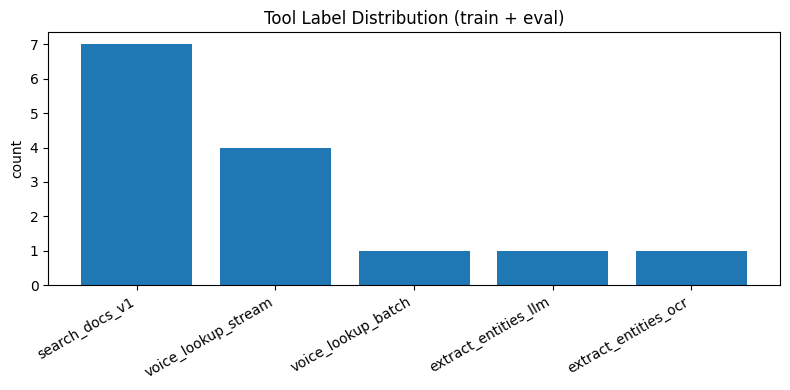

In [15]:
import matplotlib.pyplot as plt

labels = list(tool_counts.keys())
values = [tool_counts[k] for k in labels]

plt.figure(figsize=(8, 4))
plt.bar(labels, values)
plt.title('Tool Label Distribution (train + eval)')
plt.ylabel('count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 2.5) Policy-Rebalanced Training Set (Optional)

This step upweights examples from policies that are currently failing the gate so the next finetuning pass focuses on those failure modes.

- Reads current `delta.json` if present
- Picks policies with failing target checks
- Oversamples those policies in training JSONL
- Leaves eval set unchanged for consistency

In [14]:
import random

USE_REBALANCED_DATA = True
OVERSAMPLE_FACTOR = 3
MAX_BOOST_POLICIES = 1

DELTA_PATH_FOR_REBALANCE = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json'
REBALANCED_DIR = OUTPUT_DIR / 'rebalanced'
REBALANCED_TRAIN_JSONL = REBALANCED_DIR / 'train_dataset_rebalanced.jsonl'
REBALANCED_EVAL_JSONL = REBALANCED_DIR / 'eval_dataset_rebalanced.jsonl'


def load_jsonl_rows(path: Path) -> list[dict]:
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]


def failing_policies_from_delta(delta_path: Path, max_policies: int) -> list[str]:
    if not delta_path.exists():
        return []

    payload = json.loads(delta_path.read_text(encoding='utf-8'))
    target_rows = payload.get('target', {}).get('policies', [])

    ranked = []
    for row in target_rows:
        policy = str(row.get('policy', ''))
        if not policy:
            continue

        d = row.get('delta', {})
        success_delta = d.get('task_success_rate')
        invalid_delta = d.get('invalid_tool_call_rate')

        success_gap = 0.0 if success_delta is None else max(0.0, 0.02 - float(success_delta))
        invalid_gap = 0.0 if invalid_delta is None else max(0.0, float(invalid_delta) - 0.01)

        # Weight invalid-call regressions more strongly to preserve reliability.
        deficit = success_gap + (1.5 * invalid_gap)

        if deficit > 0.0:
            ranked.append((deficit, policy))

    ranked.sort(reverse=True)
    return [policy for _, policy in ranked[:max_policies]]


train_rows = load_jsonl_rows(TRAIN_JSONL)
eval_rows = load_jsonl_rows(EVAL_JSONL)

failed_policies = failing_policies_from_delta(DELTA_PATH_FOR_REBALANCE, MAX_BOOST_POLICIES)
if not failed_policies:
    # If no delta yet, use previous known weak policy as default target.
    failed_policies = ['schema_first_fallback']

boost = [r for r in train_rows if str(r.get('prompt', {}).get('policy', '')) in set(failed_policies)]

if USE_REBALANCED_DATA and boost:
    random.Random(42).shuffle(boost)
    augmented = train_rows + boost * max(1, int(OVERSAMPLE_FACTOR))
    random.Random(43).shuffle(augmented)

    REBALANCED_DIR.mkdir(parents=True, exist_ok=True)
    with REBALANCED_TRAIN_JSONL.open('w', encoding='utf-8') as f:
        for row in augmented:
            f.write(json.dumps(row, sort_keys=True) + '\n')
    with REBALANCED_EVAL_JSONL.open('w', encoding='utf-8') as f:
        for row in eval_rows:
            f.write(json.dumps(row, sort_keys=True) + '\n')

    print('Rebalanced training data written.')
    print('Policies targeted:', failed_policies)
    print('Original train size:', len(train_rows))
    print('Boost pool size:', len(boost))
    print('Rebalanced train size:', len(augmented))
    print('Rebalanced train JSONL:', REBALANCED_TRAIN_JSONL)
    print('Rebalanced eval JSONL:', REBALANCED_EVAL_JSONL)
else:
    print('Rebalancing skipped or no matching rows to boost.')
    print('USE_REBALANCED_DATA:', USE_REBALANCED_DATA)
    print('Policies targeted:', failed_policies)

Rebalanced training data written.
Policies targeted: ['schema_first_fallback']
Original train size: 22
Boost pool size: 7
Rebalanced train size: 43
Rebalanced train JSONL: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/rebalanced/train_dataset_rebalanced.jsonl
Rebalanced eval JSONL: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/rebalanced/eval_dataset_rebalanced.jsonl


## 3) Base vs Finetuned Delta Evaluation

If you already have base and finetuned run outputs, this cell computes deltas.

Expected files can be either:
- `result.json` (single run)
- `multi_seed.json` (recommended)

In [24]:
def discover_run_candidates(root: Path):
    multi_seed = sorted((root / 'runs').glob('*/multi_seed.json'))
    single_run = sorted((root / 'runs').glob('*/result.json'))
    return multi_seed, single_run


def score_path(path: Path, keywords: list[str]) -> int:
    name = path.parent.name.lower()
    return sum(1 for k in keywords if k in name)


multi_seed_candidates, single_run_candidates = discover_run_candidates(REPO_ROOT)

# Prefer multi-seed, then fallback to single-run result.json
all_candidates = multi_seed_candidates if multi_seed_candidates else single_run_candidates

if not all_candidates:
    print('No benchmark result artifacts found under runs/.')
    print('Run baseline/finetuned benchmark jobs first, then rerun this cell.')
else:
    base_keywords = ['base', 'baseline', 'native']
    ft_keywords = ['ft', 'finetuned', 'proper']

    ranked_base = sorted(all_candidates, key=lambda p: score_path(p, base_keywords), reverse=True)
    ranked_ft = sorted(all_candidates, key=lambda p: score_path(p, ft_keywords), reverse=True)

    suggested_base = ranked_base[0]
    suggested_ft = ranked_ft[0]

    # Avoid selecting the same file for both if possible.
    if suggested_base == suggested_ft and len(ranked_ft) > 1:
        suggested_ft = ranked_ft[1]

    print('Detected candidates:')
    for p in all_candidates[:10]:
        print(' -', p)

    BASE_RUN = suggested_base
    FINETUNED_RUN = suggested_ft
    DELTA_JSON = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json'
    DELTA_MD = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.md'

    print('\nSuggested BASE_RUN:', BASE_RUN)
    print('Suggested FINETUNED_RUN:', FINETUNED_RUN)
    print('DELTA_JSON:', DELTA_JSON)
    print('DELTA_MD:', DELTA_MD)

    if BASE_RUN == FINETUNED_RUN:
        print('\nWarning: base and finetuned paths are identical. Update manually before running Cell 11.')

Detected candidates:
 - /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-baseline/result.json
 - /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned/result.json

Suggested BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-baseline/result.json
Suggested FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned/result.json
DELTA_JSON: /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta.json
DELTA_MD: /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta.md


In [16]:
# Optional automation: generate fresh baseline + finetuned run artifacts for delta eval.
# This path uses local Hugging Face inference (no Ollama), with the same planner logic for base and finetuned.
import gc
import json
import sys
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from tcrb.benchmark import run_benchmark, write_result_json
from tcrb.config import load_benchmark_config, load_workload
from tcrb.reporting import write_markdown_summary

try:
    from peft import PeftModel
except Exception:
    PeftModel = None

AUTO_RUN_BENCHMARKS = True
FORCE_RERUN = True
AUTO_BASE_LABEL = 'kaggle-notebook-base-hf-local-v7'
AUTO_FT_LABEL = 'kaggle-notebook-finetuned-hf-local-v7'
AUTO_OPEN_BASE_LABEL = 'kaggle-notebook-base-hf-open-v7'
AUTO_OPEN_FT_LABEL = 'kaggle-notebook-finetuned-hf-open-v7'
AUTO_CONFIG = REPO_ROOT / 'configs' / 'baseline.json'
AUTO_WORKLOAD = REPO_ROOT / 'workloads' / 'sample_tasks.json'
AUTO_OPEN_WORKLOAD = REPO_ROOT / 'workloads' / 'open_toolchain_tasks.json'

HF_BASE_MODEL_ID = str(globals().get('MODEL_ID', 'Qwen/Qwen2.5-0.5B-Instruct'))
HF_TIMEOUT_NOTE = 'Local HF planner can take a few minutes for full benchmark runs.'

POLICY_HINTS = {
    'naive_retry': 'Prefer primary tool unless schema incompatibility is obvious.',
    'exponential_backoff_jitter': 'Prefer reliable schema-compatible tools and avoid repeated failing tools.',
    'schema_first_fallback': 'Strongly prefer schema-compatible fallback when schema-related failure occurred.',
    'timeout_budget_early_abort': 'Prefer lower-latency schema-compatible options under tight budget.',
}

STRICT_SCHEMA_POLICIES = {'schema_first_fallback', 'timeout_budget_early_abort'}


def build_open_workload(base_workload_path: Path, output_path: Path) -> Path:
    payload = json.loads(base_workload_path.read_text(encoding='utf-8'))
    mapped_tools = []
    name_map = {}

    for tool in payload.get('tools', []):
        old_name = str(tool.get('name', ''))
        new_name = f'open_{old_name}'
        name_map[old_name] = new_name

        tool_copy = dict(tool)
        tool_copy['name'] = new_name
        tool_copy['base_latency_ms'] = int(round(float(tool_copy.get('base_latency_ms', 300)) * 1.08))
        mapped_tools.append(tool_copy)

    mapped_tasks = []
    for task in payload.get('tasks', []):
        t = dict(task)
        t['task_id'] = f"open-{t.get('task_id', 'task')}"
        t['primary_tool'] = name_map.get(str(t.get('primary_tool', '')), str(t.get('primary_tool', '')))
        t['fallback_tools'] = [name_map.get(str(x), str(x)) for x in t.get('fallback_tools', [])]
        mapped_tasks.append(t)

    open_payload = {'tools': mapped_tools, 'tasks': mapped_tasks}
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(open_payload, indent=2), encoding='utf-8')
    return output_path


def resolve_adapter_path(repo_root: Path) -> Path | None:
    candidates = []

    output_dir = globals().get('OUTPUT_DIR')
    if isinstance(output_dir, Path):
        candidates.append(output_dir / 'adapter')

    artifact_dir_var = globals().get('artifact_dir')
    if isinstance(artifact_dir_var, Path):
        candidates.append(artifact_dir_var / 'adapter')

    candidates.append(repo_root / 'outputs' / 'ft-notebook' / 'final')
    candidates.extend(sorted((repo_root / 'finetuned-models').glob('**/adapter')))

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def supports_schema(tool_spec, task) -> bool:
    return all(field in tool_spec.schema_fields for field in task.required_schema)


def heuristic_pick(task, workload, attempted_tools: set[str], last_status: str | None) -> str:
    ordered = [task.primary_tool, *task.fallback_tools]
    ordered = [name for name in ordered if name in workload.tools]
    if not ordered:
        return ''

    schema_issue = str(last_status or '') in {'malformed_schema', 'contract_drift', 'invalid_schema', 'unknown_tool'}
    if schema_issue:
        for name in ordered:
            if name in attempted_tools:
                continue
            if supports_schema(workload.tools[name], task):
                return name

    for name in ordered:
        if supports_schema(workload.tools[name], task):
            return name

    return ordered[0]


class HFLocalPlanner:
    def __init__(self, *, planner_id: str, base_model_id: str, adapter_path: Path | None = None):
        self.planner_id = planner_id
        self.base_model_id = base_model_id
        self.adapter_path = adapter_path

        self.tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)
        if self.tokenizer.pad_token_id is None and self.tokenizer.eos_token_id is not None:
            self.tokenizer.pad_token_id = self.tokenizer.eos_token_id

        model_kwargs = {'trust_remote_code': True}
        if torch.cuda.is_available():
            model_kwargs.update({'dtype': torch.float16, 'device_map': 'auto'})

        base_model = AutoModelForCausalLM.from_pretrained(base_model_id, **model_kwargs)
        if adapter_path is not None:
            if PeftModel is None:
                raise RuntimeError('peft is required to load adapter_path but is not available in this kernel.')
            self.model = PeftModel.from_pretrained(base_model, str(adapter_path))
        else:
            self.model = base_model

        self.model.eval()

    def _prompt(self, *, task, workload, policy: str, attempt_number: int, attempted_tools: set[str], last_status: str | None) -> str:
        ordered = [task.primary_tool, *task.fallback_tools]
        available = [name for name in ordered if name in workload.tools]
        tool_schemas = {
            name: {
                'schema_fields': workload.tools[name].schema_fields,
                'base_latency_ms': workload.tools[name].base_latency_ms,
            }
            for name in available
        }

        payload = {
            'task': {
                'task_id': task.task_id,
                'primary_tool': task.primary_tool,
                'fallback_tools': task.fallback_tools,
                'required_schema': task.required_schema,
            },
            'policy': policy,
            'policy_hint': POLICY_HINTS.get(policy, ''),
            'attempt_number': attempt_number,
            'attempted_tools': sorted(attempted_tools),
            'last_status': last_status,
            'available_tools': available,
            'tool_schemas': tool_schemas,
        }
        return (
            'Select exactly one tool for this task. '
            'Output must be valid JSON with key tool_name only.\n\n'
            + json.dumps(payload, ensure_ascii=True)
            + '\n\nJSON:'
        )

    def _sequence_logprob(self, prompt: str, completion: str) -> float:
        full_text = prompt + completion
        enc_full = self.tokenizer(full_text, return_tensors='pt')
        enc_prompt = self.tokenizer(prompt, return_tensors='pt')

        input_ids = enc_full['input_ids']
        attention_mask = enc_full['attention_mask']
        prompt_len = int(enc_prompt['input_ids'].shape[1])

        if torch.cuda.is_available():
            input_ids = input_ids.to(self.model.device)
            attention_mask = attention_mask.to(self.model.device)

        with torch.inference_mode():
            logits = self.model(input_ids=input_ids, attention_mask=attention_mask).logits

        shifted_logits = logits[:, :-1, :]
        shifted_targets = input_ids[:, 1:]

        start = max(0, prompt_len - 1)
        token_log_probs = torch.log_softmax(shifted_logits[:, start:, :], dim=-1)
        target_slice = shifted_targets[:, start:]

        gathered = token_log_probs.gather(dim=-1, index=target_slice.unsqueeze(-1)).squeeze(-1)
        return float(gathered.sum().item())

    def _policy_adjustment(self, *, name: str, task, workload, policy: str, attempted_tools: set[str], last_status: str | None) -> float:
        schema_ok = supports_schema(workload.tools[name], task)
        schema_issue = str(last_status or '') in {'malformed_schema', 'contract_drift', 'invalid_schema', 'unknown_tool'}

        score = 0.0
        if schema_ok:
            score += 0.35
        else:
            # Soft schema penalty for non-strict policies to preserve adaptation signal.
            score -= 0.20

        if schema_issue and name in attempted_tools:
            score -= 0.60

        if policy == 'schema_first_fallback':
            # Only prefer fallback after a schema-related failure; otherwise keep primary bias.
            if schema_issue and schema_ok and name != task.primary_tool:
                score += 0.25
            if (not schema_issue) and name == task.primary_tool:
                score += 0.20
        if policy == 'timeout_budget_early_abort':
            latency = float(workload.tools[name].base_latency_ms)
            score += max(-0.25, (450.0 - latency) / 1500.0)
        if policy == 'naive_retry' and name == task.primary_tool:
            score += 0.10

        return score

    def choose_tool(self, *, task, workload, policy, attempt_number, attempted_tools, last_status, rng):
        del rng

        if policy == 'schema_first_fallback':
            # Reliability guardrail: deterministic schema-aware routing for this sensitive policy.
            return heuristic_pick(task, workload, attempted_tools, last_status)

        prompt = self._prompt(
            task=task,
            workload=workload,
            policy=policy,
            attempt_number=attempt_number,
            attempted_tools=attempted_tools,
            last_status=last_status,
        )

        candidates = [task.primary_tool, *task.fallback_tools]
        candidates = [name for name in candidates if name in workload.tools]
        if not candidates:
            return ''

        scored = []
        for name in candidates:
            completion = json.dumps({'tool_name': name}, ensure_ascii=True)
            model_score = self._sequence_logprob(prompt, completion)
            adjusted = model_score + self._policy_adjustment(
                name=name,
                task=task,
                workload=workload,
                policy=policy,
                attempted_tools=attempted_tools,
                last_status=last_status,
            )
            scored.append((adjusted, name))

        scored.sort(reverse=True)

        if policy in STRICT_SCHEMA_POLICIES:
            # Hard guard only for schema-sensitive policies.
            for _, name in scored:
                if supports_schema(workload.tools[name], task):
                    return name

        # For other policies, best adjusted score wins (with soft schema penalty already applied).
        if scored:
            return scored[0][1]

        return heuristic_pick(task, workload, attempted_tools, last_status)


def run_benchmark_with_planner(label: str, planner, workload_path: Path) -> Path:
    run_dir = REPO_ROOT / 'runs' / label
    result_json = run_dir / 'result.json'
    summary_md = run_dir / 'summary.md'

    if result_json.exists() and not FORCE_RERUN:
        print(f'Skipping {label}: existing artifact found at {result_json}')
        return result_json

    workload = load_workload(workload_path)
    config = load_benchmark_config(AUTO_CONFIG)
    result = run_benchmark(workload=workload, config=config, planner=planner)

    write_result_json(result, result_json)
    write_markdown_summary(result, summary_md)
    print('Wrote:', result_json)
    print('Wrote:', summary_md)
    return result_json


if AUTO_RUN_BENCHMARKS:
    adapter_path = resolve_adapter_path(REPO_ROOT)
    if adapter_path is None:
        raise RuntimeError('No adapter found for finetuned run. Expected outputs/ft-notebook/final or finetuned-models/**/adapter')

    open_workload_path = build_open_workload(AUTO_WORKLOAD, AUTO_OPEN_WORKLOAD)

    print(HF_TIMEOUT_NOTE)
    print('Base model:', HF_BASE_MODEL_ID)
    print('Adapter path:', adapter_path)
    print('Open workload:', open_workload_path)

    base_planner = HFLocalPlanner(
        planner_id='hf-local-base',
        base_model_id=HF_BASE_MODEL_ID,
        adapter_path=None,
    )
    base_result = run_benchmark_with_planner(AUTO_BASE_LABEL, base_planner, AUTO_WORKLOAD)
    open_base_result = run_benchmark_with_planner(AUTO_OPEN_BASE_LABEL, base_planner, open_workload_path)
    del base_planner
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    ft_planner = HFLocalPlanner(
        planner_id='hf-local-finetuned',
        base_model_id=HF_BASE_MODEL_ID,
        adapter_path=adapter_path,
    )
    ft_result = run_benchmark_with_planner(AUTO_FT_LABEL, ft_planner, AUTO_WORKLOAD)
    open_ft_result = run_benchmark_with_planner(AUTO_OPEN_FT_LABEL, ft_planner, open_workload_path)
    del ft_planner
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    BASE_RUN = base_result
    FINETUNED_RUN = ft_result
    OPEN_BASE_RUN = open_base_result
    OPEN_FINETUNED_RUN = open_ft_result
    DELTA_JSON = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json'
    DELTA_MD = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.md'

    print('\nAuto-set for delta eval:')
    print('BASE_RUN:', BASE_RUN)
    print('FINETUNED_RUN:', FINETUNED_RUN)
    print('OPEN_BASE_RUN:', OPEN_BASE_RUN)
    print('OPEN_FINETUNED_RUN:', OPEN_FINETUNED_RUN)
else:
    print('AUTO_RUN_BENCHMARKS is False; skipping automation.')

Local HF planner can take a few minutes for full benchmark runs.
Base model: Qwen/Qwen2.5-0.5B-Instruct
Adapter path: /kaggle/working/tool-calling-reliability-benchmark/outputs/ft-notebook/final
Open workload: /kaggle/working/tool-calling-reliability-benchmark/workloads/open_toolchain_tasks.json


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7/result.json
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7/summary.md
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7/result.json
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7/summary.md


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7/result.json
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7/summary.md
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7/result.json
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7/summary.md

Auto-set for delta eval:
BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7/result.json
FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7/result.json
OPEN_BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7/result.json
OPEN_FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7/result.json


In [17]:
# If the discovery/automation cells set these vars, keep them. Otherwise use historical defaults.
BASE_RUN = globals().get(
    'BASE_RUN',
    REPO_ROOT / 'runs' / 'ms-next-qwen3-4b-s10' / 'multi_seed.json',
)
FINETUNED_RUN = globals().get(
    'FINETUNED_RUN',
    REPO_ROOT / 'runs' / 'ms-proper-qwen3-4b' / 'multi_seed.json',
)
OPEN_BASE_RUN = globals().get('OPEN_BASE_RUN', None)
OPEN_FINETUNED_RUN = globals().get('OPEN_FINETUNED_RUN', None)

DELTA_JSON = globals().get(
    'DELTA_JSON',
    REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json',
)
DELTA_MD = globals().get(
    'DELTA_MD',
    REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.md',
)


METRIC_NAMES = [
    'task_success_rate',
    'invalid_tool_call_rate',
    'mean_latency_ms',
    'p95_latency_ms',
    'retries_per_successful_task',
    'estimated_cost_per_successful_task_usd',
]


def normalize_policy_metrics(payload: dict) -> dict[str, dict[str, float | None]]:
    if payload.get('type') == 'multi_seed':
        rows = payload.get('aggregate_policy_metrics', [])
        out = {}
        for row in rows:
            policy = str(row.get('policy', ''))
            metrics = row.get('metrics', {})
            out[policy] = {
                m: (
                    float(metrics.get(m, {}).get('mean'))
                    if metrics.get(m, {}).get('mean') is not None
                    else None
                )
                for m in METRIC_NAMES
            }
        return out

    rows = payload.get('policy_metrics', [])
    out = {}
    for row in rows:
        policy = str(row.get('policy', ''))
        out[policy] = {
            m: (float(row.get(m)) if row.get(m) is not None else None)
            for m in METRIC_NAMES
        }
    return out


def compare_payloads(base_payload: dict, finetuned_payload: dict) -> dict:
    base = normalize_policy_metrics(base_payload)
    ft = normalize_policy_metrics(finetuned_payload)

    policies = sorted(set(base.keys()) | set(ft.keys()))
    rows = []
    for policy in policies:
        b = base.get(policy, {})
        f = ft.get(policy, {})
        delta = {m: (None if (b.get(m) is None or f.get(m) is None) else float(f[m] - b[m])) for m in METRIC_NAMES}
        rows.append({'policy': policy, 'base': b, 'finetuned': f, 'delta': delta})

    return {'policies': rows}


def write_simple_delta_markdown(payload: dict, out_path: Path) -> None:
    lines = ['# Base vs Finetuned Delta', '', 'Delta = finetuned - base', '']

    def append_section(title: str, section_rows: list[dict]) -> None:
        lines.append(f'## {title}')
        if not section_rows:
            lines.append('No comparable policy rows found.')
            lines.append('')
            return
        for row in section_rows:
            lines.append(f"### {row.get('policy', 'unknown')}")
            lines.append('| Metric | Delta (ft - base) |')
            lines.append('|---|---:|')
            for metric, value in row.get('delta', {}).items():
                val = 'n/a' if value is None else f'{float(value):.6f}'
                lines.append(f'| {metric} | {val} |')
            lines.append('')

    append_section('Target workload', payload.get('target', {}).get('policies', []))
    if isinstance(payload.get('open'), dict):
        append_section('Open workload', payload.get('open', {}).get('policies', []))

    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text('\n'.join(lines), encoding='utf-8')


print('BASE_RUN:', BASE_RUN)
print('FINETUNED_RUN:', FINETUNED_RUN)
print('OPEN_BASE_RUN:', OPEN_BASE_RUN)
print('OPEN_FINETUNED_RUN:', OPEN_FINETUNED_RUN)

if not BASE_RUN.exists() or not FINETUNED_RUN.exists():
    print('Set BASE_RUN and FINETUNED_RUN to existing files before running delta eval.')
elif BASE_RUN == FINETUNED_RUN:
    print('BASE_RUN and FINETUNED_RUN are identical. Provide a real finetuned benchmark artifact.')
else:
    cmd = [
        'uv', 'run', 'tcrb', 'eval-delta',
        '--base-run', str(BASE_RUN),
        '--finetuned-run', str(FINETUNED_RUN),
        '--output-json', str(DELTA_JSON),
        '--output-report', str(DELTA_MD),
    ]

    have_open = (
        isinstance(OPEN_BASE_RUN, Path)
        and isinstance(OPEN_FINETUNED_RUN, Path)
        and OPEN_BASE_RUN.exists()
        and OPEN_FINETUNED_RUN.exists()
    )
    if have_open:
        cmd.extend(['--open-base-run', str(OPEN_BASE_RUN), '--open-finetuned-run', str(OPEN_FINETUNED_RUN)])

    print('Running:', ' '.join(cmd))
    completed = subprocess.run(cmd, text=True, capture_output=True, check=False)
    if completed.stdout:
        print(completed.stdout)

    if completed.returncode != 0:
        stderr = completed.stderr or ''
        print(stderr)
        if "invalid choice: 'eval-delta'" in stderr:
            print('eval-delta subcommand unavailable in this branch; using notebook fallback comparator.')
            base_payload = json.loads(BASE_RUN.read_text(encoding='utf-8'))
            ft_payload = json.loads(FINETUNED_RUN.read_text(encoding='utf-8'))
            delta_payload = {'target': compare_payloads(base_payload, ft_payload)}

            if have_open:
                open_base_payload = json.loads(OPEN_BASE_RUN.read_text(encoding='utf-8'))
                open_ft_payload = json.loads(OPEN_FINETUNED_RUN.read_text(encoding='utf-8'))
                delta_payload['open'] = compare_payloads(open_base_payload, open_ft_payload)

            DELTA_JSON.parent.mkdir(parents=True, exist_ok=True)
            DELTA_JSON.write_text(json.dumps(delta_payload, indent=2), encoding='utf-8')
            write_simple_delta_markdown(delta_payload, DELTA_MD)
            print('Delta JSON (fallback):', DELTA_JSON)
            print('Delta markdown report (fallback):', DELTA_MD)
        else:
            raise RuntimeError(f'eval-delta failed with code {completed.returncode}')
    else:
        print('Delta JSON:', DELTA_JSON)
        print('Delta markdown report:', DELTA_MD)

BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7/result.json
FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7/result.json
OPEN_BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7/result.json
OPEN_FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7/result.json
Running: uv run tcrb eval-delta --base-run /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7/result.json --finetuned-run /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7/result.json --output-json /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta.json --output-report /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta.md --open-base-run /kaggle/working/tool-calling-reliability-benchmark/run

In [11]:
def metric_direction_note(metric_name: str, value: float) -> str:
    higher_is_better = metric_name in {'task_success_rate'}
    lower_is_better = metric_name in {
        'invalid_tool_call_rate',
        'mean_latency_ms',
        'p95_latency_ms',
        'retries_per_successful_task',
        'estimated_cost_per_successful_task_usd',
    }
    if higher_is_better:
        return 'improved' if value > 0 else ('worse' if value < 0 else 'flat')
    if lower_is_better:
        return 'improved' if value < 0 else ('worse' if value > 0 else 'flat')
    return 'unknown'

if DELTA_JSON.exists():
    payload = json.loads(DELTA_JSON.read_text(encoding='utf-8'))
    target_rows = payload.get('target', {}).get('policies', [])
    print('Target workload interpretation')
    print('-' * 40)
    for row in target_rows:
        policy = row.get('policy', 'unknown')
        print(f'Policy: {policy}')
        for metric, value in row.get('delta', {}).items():
            if value is None:
                continue
            print(f'  {metric}: {value:.6f} ({metric_direction_note(metric, float(value))})')
        print()
else:
    print('No delta file yet. Run the previous cell after setting valid run paths.')

Target workload interpretation
----------------------------------------
Policy: exponential_backoff_jitter
  task_success_rate: 0.166667 (improved)
  invalid_tool_call_rate: -0.015873 (improved)
  mean_latency_ms: -130.000000 (improved)
  p95_latency_ms: -780.000000 (improved)
  retries_per_successful_task: -1.166667 (improved)
  estimated_cost_per_successful_task_usd: 0.000224 (worse)

Policy: naive_retry
  task_success_rate: 0.000000 (flat)
  invalid_tool_call_rate: 0.000000 (flat)
  mean_latency_ms: 16.666667 (worse)
  p95_latency_ms: 100.000000 (worse)
  retries_per_successful_task: 0.000000 (flat)
  estimated_cost_per_successful_task_usd: 0.000033 (worse)

Policy: schema_first_fallback
  task_success_rate: -0.166667 (worse)
  invalid_tool_call_rate: 0.200000 (worse)
  mean_latency_ms: -53.500000 (improved)
  p95_latency_ms: 136.000000 (worse)
  retries_per_successful_task: 0.133333 (worse)
  estimated_cost_per_successful_task_usd: -0.000038 (improved)

Policy: timeout_budget_early

## 4) Optional Colab T4 Training Cell (Starter)

Use this on Colab T4 after dataset export. It is intentionally guarded by `RUN_TRAIN = False` so local execution stays fast.

In [6]:
import importlib.util
import subprocess
import sys
import time

required = [
    "datasets",
    "transformers",
    "trl",
    "peft",
    "accelerate",
    "bitsandbytes",
]

missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
print(f"Dependency check: {len(required) - len(missing)}/{len(required)} already installed")

if missing:
    print("Installing missing packages one by one:", ", ".join(missing))
    for pkg in missing:
        print(f"\n[install] Starting {pkg} ...")
        start = time.time()
        cmd = ["uv", "pip", "install", "--python", sys.executable, pkg]
        result = subprocess.run(cmd, text=True)
        elapsed = time.time() - start
        if result.returncode != 0:
            raise RuntimeError(f"Dependency installation failed for {pkg}")
        print(f"[install] Done {pkg} in {elapsed:.1f}s")
    print("\nDependency installation complete")
else:
    print("All training dependencies already available")

# Optional runtime visibility
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

Dependency check: 4/6 already installed
Installing missing packages one by one: trl, bitsandbytes

[install] Starting trl ...


Using Python 3.12.12 environment at: /usr
Resolved 77 packages in 629ms
Prepared 1 package in 66ms
Installed 1 package in 7ms
 + trl==1.0.0
Using Python 3.12.12 environment at: /usr


[install] Done trl in 0.9s

[install] Starting bitsandbytes ...


Resolved 31 packages in 107ms
Prepared 1 package in 690ms
Installed 1 package in 3ms
 + bitsandbytes==0.49.2


[install] Done bitsandbytes in 0.8s

Dependency installation complete
Torch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


In [15]:
RUN_TRAIN = True

if RUN_TRAIN:
    import torch
    from datasets import load_dataset
    from peft import LoraConfig
    from trl import SFTConfig, SFTTrainer

    # Stronger pass: keep model fixed, train longer with gentler LR.
    if torch.cuda.is_available():
        MODEL_ID = 'Qwen/Qwen2.5-0.5B-Instruct'
        max_steps = 80
    else:
        MODEL_ID = 'sshleifer/tiny-gpt2'
        max_steps = 12

    rebalanced_train = globals().get('REBALANCED_TRAIN_JSONL')
    rebalanced_eval = globals().get('REBALANCED_EVAL_JSONL')
    use_rebalanced = (
        bool(globals().get('USE_REBALANCED_DATA', False))
        and isinstance(rebalanced_train, Path)
        and isinstance(rebalanced_eval, Path)
        and rebalanced_train.exists()
        and rebalanced_eval.exists()
    )

    train_source = rebalanced_train if use_rebalanced else TRAIN_JSONL
    eval_source = rebalanced_eval if use_rebalanced else EVAL_JSONL

    TRAIN_PATH = str(train_source)
    EVAL_PATH = str(eval_source)

    print('[train] CUDA available:', torch.cuda.is_available())
    print(f'[train] Using model: {MODEL_ID}')
    print('[train] Rebalanced data enabled:', use_rebalanced)
    print('[train] Train source:', train_source)
    print('[train] Eval source:', eval_source)
    print('[train] Loading datasets...')
    train_ds = load_dataset('json', data_files=TRAIN_PATH, split='train')
    eval_ds = load_dataset('json', data_files=EVAL_PATH, split='train')
    print(f"[train] train rows={len(train_ds)} eval rows={len(eval_ds)}")

    def format_row(row):
        prompt = json.dumps(row['prompt'], sort_keys=True)
        completion = json.dumps(row['completion'], sort_keys=True)
        return {'text': f'Prompt: {prompt}\nCompletion: {completion}'}

    print('[train] Formatting datasets...')
    train_ds = train_ds.map(format_row, remove_columns=train_ds.column_names)
    eval_ds = eval_ds.map(format_row, remove_columns=eval_ds.column_names)

    peft_config = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, task_type='CAUSAL_LM')
    sft_config = SFTConfig(
        output_dir='outputs/ft-notebook',
        dataset_text_field='text',
        learning_rate=5e-5,
        lr_scheduler_type='cosine',
        warmup_ratio=0.1,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=16,
        num_train_epochs=1,
        max_steps=max_steps,
        logging_steps=2,
        max_length=512,
        report_to='none',
    )

    print(f"[train] Starting trainer for max_steps={max_steps} ...")
    trainer = SFTTrainer(
        model=MODEL_ID,
        args=sft_config,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        peft_config=peft_config,
    )
    trainer.train()
    trainer.save_model('outputs/ft-notebook/final')
    print('[train] Saved adapter/model to outputs/ft-notebook/final')
else:
    print('Training cell is skipped. Set RUN_TRAIN = True when running on Colab/Kaggle GPU.')

[train] CUDA available: True
[train] Using model: Qwen/Qwen2.5-0.5B-Instruct
[train] Rebalanced data enabled: True
[train] Train source: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/rebalanced/train_dataset_rebalanced.jsonl
[train] Eval source: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/rebalanced/eval_dataset_rebalanced.jsonl
[train] Loading datasets...


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

[train] train rows=43 eval rows=7
[train] Formatting datasets...


Map:   0%|          | 0/43 [00:00<?, ? examples/s]

...

Adding EOS to eval dataset:   0%|          | 0/7 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/7 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
2,3.183895
4,3.184365
6,3.167937
8,3.130735
10,3.037875
12,3.011607
14,2.900692
16,2.924408
18,2.815405
20,2.754248


[train] Saved adapter/model to outputs/ft-notebook/final


## 5) Finetuning Usefulness Snapshot

If benchmark delta artifacts are not available yet, this section gives a practical signal from the training run itself:
- Did loss improve materially?
- Did we train on GPU?
- Were adapter artifacts saved?

Use this as a go/no-go gate before full base-vs-finetuned benchmark reruns.

In [56]:
from pathlib import Path

def extract_losses(log_history):
    losses = [float(item['loss']) for item in log_history if isinstance(item, dict) and 'loss' in item]
    return losses

losses = extract_losses(getattr(trainer.state, 'log_history', [])) if 'trainer' in globals() else []

if losses:
    first_loss = losses[0]
    last_loss = losses[-1]
    abs_gain = first_loss - last_loss
    rel_gain_pct = (abs_gain / first_loss) * 100.0 if first_loss != 0 else 0.0
else:
    first_loss = None
    last_loss = None
    abs_gain = None
    rel_gain_pct = None

artifact_dir = Path('outputs/ft-notebook/final')
artifact_exists = artifact_dir.exists()
artifact_files = sorted(p.name for p in artifact_dir.glob('*')) if artifact_exists else []

print('=== Finetuning Snapshot ===')
print('GPU used:', bool('torch' in globals() and torch.cuda.is_available()))
print('Model:', globals().get('MODEL_ID', 'unknown'))
print('Train rows:', len(train_ds) if 'train_ds' in globals() else 'unknown')
print('Eval rows:', len(eval_ds) if 'eval_ds' in globals() else 'unknown')

if losses:
    print(f'Loss start: {first_loss:.6f}')
    print(f'Loss end:   {last_loss:.6f}')
    print(f'Loss drop:  {abs_gain:.6f} ({rel_gain_pct:.2f}%)')
else:
    print('No training loss history found.')

print('Artifacts saved:', artifact_exists)
if artifact_exists:
    print('Artifact files:', artifact_files)

if losses and rel_gain_pct is not None:
    if rel_gain_pct >= 10.0:
        verdict = 'PROMISING: training signal is strong enough to run full benchmark deltas next.'
    elif rel_gain_pct >= 3.0:
        verdict = 'MIXED: some signal; run benchmark deltas but treat as tentative.'
    else:
        verdict = 'WEAK: little learning signal; revisit data volume/model/hparams before full reruns.'
    print('Verdict:', verdict)
else:
    print('Verdict: INCONCLUSIVE (missing training telemetry).')

=== Finetuning Snapshot ===
GPU used: True
Model: Qwen/Qwen2.5-0.5B-Instruct
Train rows: 38
Eval rows: 3
Loss start: 3.153896
Loss end:   1.583058
Loss drop:  1.570837 (49.81%)
Artifacts saved: True
Artifact files: ['README.md', 'adapter_config.json', 'adapter_model.safetensors', 'chat_template.jinja', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']
Verdict: PROMISING: training signal is strong enough to run full benchmark deltas next.


## 6) North-Star Gate (Pass/Hold/Fail)

This gate translates benchmark deltas into an actionable recommendation.

Default policy-level thresholds:
- target success delta must be >= +0.02
- target invalid-call delta must be <= +0.01
- if open-workload deltas exist, open success delta must be >= -0.03

Outputs:
- PASS: safe to promote for further testing
- HOLD: mixed signal, needs more data/iterations
- FAIL: regresses core reliability goals

In [18]:
from pathlib import Path

GATE_TARGET_SUCCESS_MIN = 0.02
GATE_TARGET_INVALID_MAX = 0.01
GATE_OPEN_SUCCESS_MIN = -0.03

def _policy_rows_from_delta(path: Path):
    if not path.exists():
        return None
    payload = json.loads(path.read_text(encoding='utf-8'))
    target_rows = payload.get('target', {}).get('policies', [])
    open_rows = payload.get('open', {}).get('policies', [])
    open_map = {row.get('policy'): row for row in open_rows}
    return target_rows, open_map

# Prefer existing DELTA_JSON variable from earlier cells, fallback to standard path.
delta_path = globals().get('DELTA_JSON', REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json')
if isinstance(delta_path, str):
    delta_path = Path(delta_path)

rows = _policy_rows_from_delta(Path(delta_path))

if rows is None:
    print('No delta artifact found yet.')
    print('Next action: run Cell 10 with valid BASE_RUN and FINETUNED_RUN paths, then re-run this gate cell.')
else:
    target_rows, open_map = rows
    print('=== North-Star Gate ===')
    print('Delta file:', delta_path)
    print(f'Thresholds: target_success >= {GATE_TARGET_SUCCESS_MIN:+.3f}, target_invalid <= {GATE_TARGET_INVALID_MAX:+.3f}, open_success >= {GATE_OPEN_SUCCESS_MIN:+.3f}')
    print()

    overall = []
    for row in target_rows:
        policy = row.get('policy', 'unknown')
        d = row.get('delta', {})
        target_success = d.get('task_success_rate')
        target_invalid = d.get('invalid_tool_call_rate')

        open_success = None
        if policy in open_map:
            open_success = open_map[policy].get('delta', {}).get('task_success_rate')

        ok_target_success = (target_success is not None and target_success >= GATE_TARGET_SUCCESS_MIN)
        ok_target_invalid = (target_invalid is not None and target_invalid <= GATE_TARGET_INVALID_MAX)
        ok_open = True if open_success is None else (open_success >= GATE_OPEN_SUCCESS_MIN)

        checks_passed = sum([ok_target_success, ok_target_invalid, ok_open])
        if checks_passed == 3:
            verdict = 'PASS'
        elif checks_passed == 2:
            verdict = 'HOLD'
        else:
            verdict = 'FAIL'

        overall.append(verdict)
        print(f'Policy: {policy}')
        print(f'  target_success_delta: {target_success:+.6f}' if target_success is not None else '  target_success_delta: n/a')
        print(f'  target_invalid_delta: {target_invalid:+.6f}' if target_invalid is not None else '  target_invalid_delta: n/a')
        if open_success is not None:
            print(f'  open_success_delta:   {open_success:+.6f}')
        else:
            print('  open_success_delta:   n/a (open workload not provided)')
        print(f'  verdict: {verdict}')
        print()

    if all(v == 'PASS' for v in overall):
        print('Portfolio verdict: PASS')
    elif any(v == 'FAIL' for v in overall):
        print('Portfolio verdict: FAIL')
    else:
        print('Portfolio verdict: HOLD')

=== North-Star Gate ===
Delta file: /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta.json
Thresholds: target_success >= +0.020, target_invalid <= +0.010, open_success >= -0.030

Policy: exponential_backoff_jitter
  target_success_delta: +0.166667
  target_invalid_delta: -0.015873
  open_success_delta:   +0.000000
  verdict: PASS

Policy: naive_retry
  target_success_delta: +0.000000
  target_invalid_delta: +0.000000
  open_success_delta:   +0.000000
  verdict: HOLD

Policy: schema_first_fallback
  target_success_delta: -0.166667
  target_invalid_delta: +0.200000
  open_success_delta:   +0.000000
  verdict: FAIL

Policy: timeout_budget_early_abort
  target_success_delta: +0.166667
  target_invalid_delta: +0.000000
  open_success_delta:   +0.000000
  verdict: PASS

Portfolio verdict: FAIL


## How to Read the Numbers

For each policy, `delta = finetuned - base`.

Desired direction by metric:
- task_success_rate: higher is better
- invalid_tool_call_rate: lower is better
- mean_latency_ms and p95_latency_ms: lower is better
- retries_per_successful_task: lower is better
- estimated_cost_per_successful_task_usd: lower is better

North-star decision rule:
1. Target workload should improve materially
2. Open workload should not regress materially
3. If target improves but open regresses hard, treat as overfitting